In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Generate random x values between -3 and 3
x = 6 * np.random.rand(200, 1) - 3

# Cubic function with noise
y = 0.5 * x**3 - 1.2 * x**2 + 0.9 * x + 2 + np.random.randn(200, 1)

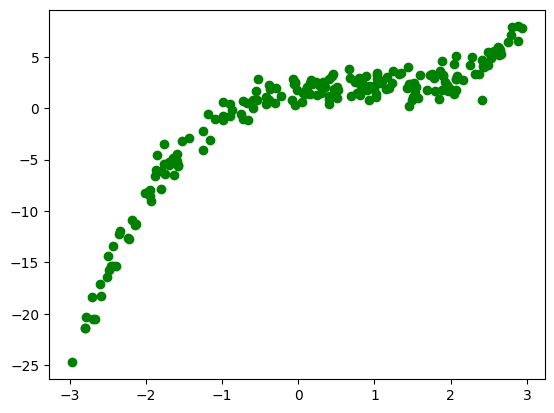

In [10]:
plt.scatter(x,y, c = 'green')

# spliting the data

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test , y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state=2)

In [14]:
y_train

array([[-2.47409301e+01],
       [ 1.80228025e+00],
       [ 5.83912665e-01],
       [ 4.27732053e+00],
       [-3.16219566e+00],
       [ 2.40101938e+00],
       [-2.05363711e+01],
       [ 1.04180220e+00],
       [-1.11150174e+00],
       [-7.93730651e+00],
       [ 3.14734028e+00],
       [ 1.78524542e+00],
       [-2.13620603e+01],
       [-3.11818543e+00],
       [-9.02913266e+00],
       [ 1.77012670e+00],
       [-5.49559751e+00],
       [ 1.65890929e+00],
       [ 2.03398921e+00],
       [ 5.30179613e-01],
       [ 3.33544677e+00],
       [ 7.89117686e-01],
       [-1.57038847e+01],
       [ 4.72236784e+00],
       [ 4.01705861e-01],
       [ 2.20904332e+00],
       [ 5.25211183e+00],
       [ 1.17267350e+00],
       [ 3.67862486e+00],
       [ 2.56651134e+00],
       [-1.26244862e+01],
       [-1.53948354e+01],
       [ 1.35584699e+00],
       [-1.44230942e+01],
       [ 2.54040670e+00],
       [-8.20112480e-03],
       [ 1.73168887e+00],
       [ 3.12925727e+00],
       [-1.5

# polynomial features creation

In [16]:
from sklearn.preprocessing import PolynomialFeatures

In [17]:
?PolynomialFeatures

Init signature:
PolynomialFeatures(
    degree=2,
    *,
    interaction_only=False,
    include_bias=True,
    order='C',
)
Docstring:     
Generate polynomial and interaction features.

Generate a new feature matrix consisting of all polynomial combinations
of the features with degree less than or equal to the specified degree.
For example, if an input sample is two dimensional and of the form
[a, b], the degree-2 polynomial features are [1, a, b, a^2, ab, b^2].

Read more in the :ref:`User Guide <polynomial_features>`.

Parameters
----------
degree : int or tuple (min_degree, max_degree), default=2
    If a single int is given, it specifies the maximal degree of the
    polynomial features. If a tuple `(min_degree, max_degree)` is passed,
    then `min_degree` is the minimum and `max_degree` is the maximum
    polynomial degree of the generated features. Note that `min_degree=0`
    and `min_degree=1` are equivalent as outputting the degree zero term is
    determined by `include_bi

In [53]:
# object banao
poly = PolynomialFeatures(degree = 3 , include_bias = False)

# fit/training karo
poly.fit(x_train.reshape(-1,1))

# prediction/transform 
x_train_new = poly.transform(x_train.reshape(-1,1))
x_test_new = poly.transform(x_test.reshape(-1,1))
x_train_new

array([[-2.97378676e+00,  8.84340769e+00, -2.62984087e+01],
       [ 1.88623113e+00,  3.55786788e+00,  6.71096116e+00],
       [ 4.91140291e-02,  2.41218785e-03,  1.18472264e-04],
       [ 2.04290638e+00,  4.17346646e+00,  8.52600123e+00],
       [-1.52588512e+00,  2.32832541e+00, -3.55275711e+00],
       [-5.56021245e-02,  3.09159624e-03, -1.71899319e-04],
       [-2.69191490e+00,  7.24640582e+00, -1.95067078e+01],
       [ 1.57523848e+00,  2.48137627e+00,  3.90875938e+00],
       [-9.91211334e-01,  9.82499908e-01, -9.73865044e-01],
       [-1.94547490e+00,  3.78487259e+00, -7.36337463e+00],
       [ 2.08439368e+00,  4.34469702e+00,  9.05605902e+00],
       [-1.34852290e-02,  1.81851402e-04, -2.45230780e-06],
       [-2.79736269e+00,  7.82523801e+00, -2.18900289e+01],
       [-1.16337261e+00,  1.35343584e+00, -1.57455018e+00],
       [-1.92660046e+00,  3.71178934e+00, -7.15113507e+00],
       [ 5.24371771e-01,  2.74965754e-01,  1.44184279e-01],
       [-1.58119963e+00,  2.50019225e+00

# Linear Regression

In [54]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

In [55]:
lr.fit(x_train_new, y_train)

LinearRegression()

In [56]:
y_pred = lr.predict(x_test_new)

# accuracy checking

In [57]:
from sklearn.metrics import r2_score

In [58]:
r2_score(y_test,y_pred)

0.9444542296837841

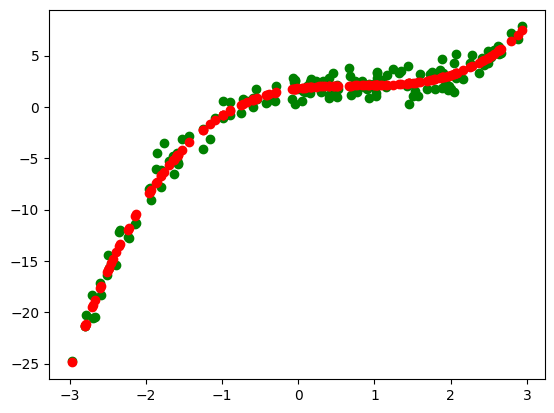

In [59]:
plt.scatter(x_train,y_train, c = 'green')
plt.scatter(x_train,lr.predict(x_train_new), c = "red" )